In [ ]:
#| default_exp meta_learning.environments.pricing_env.pricing_env

In [ ]:
#| export
import gym
from abc import ABC, abstractmethod
from typing import Union, List, Dict, Optional
import numpy as np
import matplotlib.pyplot as plt
import torch
from  ddopai.meta_learning.utils import helpers as utl
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#| export

class PricingEnv(gym.Env):
    """
    ──────────────────────────────────────────────────────────────────────────
    Single-SKU pricing environment for meta-RL (RL², variBAD, etc.)
    ──────────────────────────────────────────────────────────────────────────

    Task vector  (length = 2 · F + 3)  
        [ alpha ₀,…,alpha _{F-1},
          beta ₀,…,beta _{F-1},
          sigma,
          inv_ratio,
          horizon ]

      • *alpha* (F)    – intercept terms of the linear demand model  
      • *beta*  (F)    – slope terms (negative ⇒ demand ↓ as price ↑)  
      • *sigma*        – st.dev. of additive Gaussian demand noise  
      • *inv_ratio*    – initial inventory / horizon (0 … 1)  
      • *horizon*      – episode length (integer)

    Observation  
        [ inventory , feature₀ … feature_{F-1} ]

    Action  
        scalar price in ⁠[ p_low , p_high ].

    Reward  
        revenue = price × sales  (no holding- or stock-out costs).

    Notes for meta-RL wrappers
    --------------------------
    • **`reset_task()`** changes *only* the latent task; it does *not* start
      an episode. Call `reset()` afterwards.  
    • `info["task"]` returns the current task vector for logging /
      evaluation.  
    • Boundaries of `task_space` are set to large finite values only to keep
      Gym quiet; the code never samples from that space.

    Reproducibility
    ---------------
    This minimal version uses the **global NumPy RNG** (`np.random`).  If you
    need deterministic roll-outs in a vectorised setup, create your own
    wrapper that seeds the RNG per worker.
    """

    _BIG = 1e9  # very wide bound for observation & task spaces

    # --------------------------------------------------------------------- #
    #                         constructor                                    #
    # --------------------------------------------------------------------- #
    def __init__(self,
                 # price limits
                 p_low: float = 0.0,
                 p_high: float = 1.0,

                 # feature & task-distribution settings
                 nb_features: int = 1,
                 horizon_choices: List[int] = (500,),
                 mean_alpha: List[float] = (1.2,),
                 std_alpha: float = 0.0,
                 mean_beta: List[float] = (-0.3,),
                 std_beta: float = 0.0,
                 noise_std_choices: List[float] = (0.2,),
                 inv_ratio_mean: float = 0.5,
                 inv_ratio_std: float = 0.1,
                 function_choices: List[int] = (0,), # 0: linear, 1: log

                 # optional fixed task (otherwise sampled)
                 task: Optional[np.ndarray] = None):

        super().__init__()

        # -------- store hyper-parameters -------------------------------------
        self.nb_features       = nb_features
        self.horizon_choices   = tuple(horizon_choices)
        self.mean_alpha        = tuple(mean_alpha)
        self.std_alpha         = std_alpha
        self.mean_beta         = tuple(mean_beta)
        self.std_beta          = std_beta
        self.noise_std_choices = tuple(noise_std_choices)
        self.inv_ratio_mean    = inv_ratio_mean
        self.inv_ratio_std     = inv_ratio_std
        self.function_choices     = tuple(function_choices)
        # -------- Gym spaces --------------------------------------------------
        # action: scalar price -------------------------------------------------
        self.action_space = gym.spaces.Box(
            low=np.array([p_low],  dtype=np.float32),
            high=np.array([p_high], dtype=np.float32),
            dtype=np.float32
        )

        # observation: inventory + features -----------------------------------
        obs_dim = 1 + nb_features
        self.observation_space = gym.spaces.Box(
            low=-self._BIG, high=self._BIG,
            shape=(obs_dim,), dtype=np.float32
        )

        # task vector (never actually sampled by the library code) ------------
        self.task_dim = 2 * nb_features + 4
        self.task_space = gym.spaces.Box(
            low=-self._BIG, high=self._BIG,
            shape=(self.task_dim,), dtype=np.float32
        )
        self.seed()
        # -------- set latent task & episode ----------------------------------
        self.reset_task(task)
        self.reset()

    # ===================================================================== #
    #                      meta-learning hooks                               #
    # ===================================================================== #
    def reset_task(self, task: Optional[np.ndarray] = None) -> None:
        """
        Pick a new latent task.

        Parameters
        ----------
        task : ndarray or None
            • *None*  – sample from the task prior  
            • ndarray – use given vector (length == `task_dim`)
        """
        if task is None:
            task = self._sample_task()
        task = np.asarray(task, dtype=np.float32)
        assert task.shape == (self.task_dim,), f"task has wrong shape {task.shape}"
        self._task = task

        F = self.nb_features
        self.alpha     = task[:F]
        self.beta      = task[F:2*F]
        self.sigma     = float(task[2*F])
        self.inv_ratio = float(np.clip(task[2*F + 1], 0.00, 1.0))
        self.horizon   = int(task[2*F + 2])
        self.function = int(task[2*F + 3])

    def get_task(self) -> np.ndarray:
        """Return **copy** of the current task vector (float32)."""
        return self._task.copy()

    # ===================================================================== #
    #                       Gym interface                                   #
    # ===================================================================== #
    def reset(self):
        """Start a fresh episode under the *current* task."""
        self.t   = 0
        self.inv = float(self.horizon * self.inv_ratio)
        return self._get_obs()

    def step(self, action):
        done = False
        # ── 1. clip price into valid range ---------------------------------------
        price = float(np.clip(action, self.action_space.low[0],
                                    self.action_space.high[0]))

        # ── 2. realise (stochastic) demand ---------------------------------------
        noise   = np.random.normal(0.0, self.sigma)
        demand  = self._demand(price, noise)

        # ── 3. apply / skip inventory constraint ---------------------------------
        if self.inv_ratio == 0.0:                # ▶ unlimited stock
            sales = demand                       #   no inventory depletion
        else:                                    # ▶ finite stock
            sales = min(demand, self.inv)
            self.inv -= sales
            done = (self.inv <= 0.0)  # stock-out if inv drops to zero

        # ── 4. reward (revenue) ---------------------------------------------------
        reward = price * sales

        # ── 5. book-keeping -------------------------------------------------------
        self.t += 1
        done = done or (self.t >= self.horizon)

        obs = self._get_obs()
        info = {
            "task":   self.get_task(),
            "action": price,
            "noise":  noise,
            "demand": demand,
            "sales":  sales,
            "inv":    self.inv
        }
        return obs, reward, done, info

    def seed(self, seed=None):
        self.np_random, seed = gym.utils.seeding.np_random(seed)
        return [seed]
    # ===================================================================== #
    #                         internal helpers                               #
    # ===================================================================== #
    # ---------- task sampler --------------------------------------------------
    def _sample_task(self) -> np.ndarray:
        F = self.nb_features
        mean_alpha = float(np.random.choice(self.mean_alpha))
        mean_beta  = float(np.random.choice(self.mean_beta))
        alpha = np.random.normal(mean_alpha, self.std_alpha,  size=F)
        beta  = np.random.normal(mean_beta,  self.std_beta,   size=F)
        sigma = float(np.random.choice(self.noise_std_choices))
        inv_ratio = float(np.clip(
            np.random.normal(self.inv_ratio_mean, self.inv_ratio_std), 0.00, 1.0))
        horizon = int(np.random.choice(self.horizon_choices))
        function_choices = np.random.choice(self.function_choices)
        return np.concatenate([alpha, beta,
                               [sigma, inv_ratio, horizon, function_choices]]).astype(np.float32)

    # ---------- observation helpers ------------------------------------------
    def _get_features(self) -> np.ndarray:
        """Draw a single feature vector Xₜ."""
        if self.nb_features == 1:
            return np.ones(1, dtype=np.float32)
        scale = 1.0 / np.sqrt(self.nb_features - 1)
        return np.random.uniform(0.0, scale, size=self.nb_features).astype(np.float32)

    def _get_obs(self) -> np.ndarray:
        self._X = self._get_features()
        return np.concatenate([self._X, [self.inv]]).astype(np.float32)

    # ---------- demand model --------------------------------------------------
    def _demand(self, price: float, noise: float) -> float:
        """Linear demand with additive noise; demand ≥ 0."""
        if self.function == 1: # exp function
            mean = float(np.exp(np.dot(self._X, self.alpha)* 0.55 + np.dot(self._X, self.beta) * price))
        
        elif self.function == 2: # logit function
            zeta = np.exp(np.dot(self._X, self.alpha) + np.dot(self._X, self.beta) * price)
            mean = float(3 * np.divide(zeta, 1 + zeta)) 
            
        else: # Linear function
            mean = float(np.dot(self._X, self.alpha) + np.dot(self._X, self.beta) * price)
        return max(0.0, mean + noise)

    # ---------- visualisation stub -------------------------------------------
    @staticmethod
    def visualise_behaviour(env,
                            args,
                            policy,
                            iter_idx,
                            encoder=None,
                            reward_decoder=None,
                            image_folder=None,
                            **kwargs):
        """
        Visualise behaviour in PricingEnv: plots price (action) and revenue (reward) per timestep.
        The environment passed to this method should be a vectorised env (DummyVecEnv or SubprocVecEnv).
        """

        num_episodes = args.max_rollouts_per_task
        unwrapped_env = env.venv.unwrapped.envs[0]

        episode_all_obs = [[] for _ in range(num_episodes)]
        episode_prev_obs = [[] for _ in range(num_episodes)]
        episode_next_obs = [[] for _ in range(num_episodes)]
        episode_actions = [[] for _ in range(num_episodes)]
        episode_rewards = [[] for _ in range(num_episodes)]
        episode_returns = []
        episode_lengths = []

        if args.pass_belief_to_policy and (encoder is None):
            episode_beliefs = [[] for _ in range(num_episodes)]
        else:
            episode_beliefs = None
            
        if encoder is not None:
            episode_latent_samples = [[] for _ in range(num_episodes)]
            episode_latent_means = [[] for _ in range(num_episodes)]
            episode_latent_logvars = [[] for _ in range(num_episodes)]
        else:
            episode_latent_samples = episode_latent_means = episode_latent_logvars = None

        env.reset_task()
        [state, belief, task] = utl.reset_env(env, args)
        start_obs = state.clone()

        for episode_idx in range(num_episodes):

            curr_rollout_rew = []

            

            if encoder is not None:
                
                if episode_idx == 0 and encoder is not None:
                    # reset to prior
                    curr_latent_sample, curr_latent_mean, curr_latent_logvar, hidden_state = encoder.prior(1)
                    curr_latent_sample = curr_latent_sample[0].to(device)
                    curr_latent_mean = curr_latent_mean[0].to(device)
                    curr_latent_logvar = curr_latent_logvar[0].to(device)
                    
                episode_latent_samples[episode_idx].append(curr_latent_sample[0].clone())
                episode_latent_means[episode_idx].append(curr_latent_mean[0].clone())
                episode_latent_logvars[episode_idx].append(curr_latent_logvar[0].clone())

            episode_all_obs[episode_idx].append(start_obs.clone())
            if args.pass_belief_to_policy and (encoder is None):
                episode_beliefs[episode_idx].append(belief)
                
            for step_idx in range(env._max_episode_steps):
                
                if step_idx == 1:
                    prev_obs = start_obs.clone()
                else:
                    prev_obs = state.clone()
                    
                episode_prev_obs[episode_idx].append(prev_obs)
                
                                # act
                _, action, _ = utl.select_action(args=args,
                                                 policy=policy,
                                                 state=state.view(-1),
                                                 belief=belief,
                                                 task=task,
                                                 deterministic=True,
                                                 latent_sample=curr_latent_sample.view(-1) if (curr_latent_sample is not None) else None,
                                                 latent_mean=curr_latent_mean.view(-1) if (curr_latent_mean is not None) else None,
                                                 latent_logvar=curr_latent_logvar.view(-1) if (curr_latent_logvar is not None) else None,
                                                 )
                
                # observe reward and next obs
                [state, belief, task], (rew_raw, rew_normalised), done, infos = utl.env_step(env, action, args)

                if encoder is not None:
                    # update task embedding
                    curr_latent_sample, curr_latent_mean, curr_latent_logvar, hidden_state = encoder(
                        action.float().to(device),
                        state,
                        rew_raw.reshape((1, 1)).float().to(device),
                        prev_obs,
                        hidden_state,
                        return_prior=False)

                    episode_latent_samples[episode_idx].append(curr_latent_sample[0].clone())
                    episode_latent_means[episode_idx].append(curr_latent_mean[0].clone())
                    episode_latent_logvars[episode_idx].append(curr_latent_logvar[0].clone())

                episode_all_obs[episode_idx].append(state.clone())
                episode_next_obs[episode_idx].append(state.clone())
                episode_rewards[episode_idx].append(rew_raw.clone())
                episode_actions[episode_idx].append(action.clone())

                curr_rollout_rew.append(rew_raw.clone())
                

                if args.pass_belief_to_policy and (encoder is None):
                    episode_beliefs[episode_idx].append(belief)

                if infos[0]['done_mdp'] and not done:
                    start_obs = infos[0]['start_state']
                    start_obs = torch.from_numpy(start_obs).float().reshape((1, -1)).to(device)
                    break

            episode_returns.append(sum(curr_rollout_rew))
            episode_lengths.append(step_idx)


        # clean up

        if encoder is not None:
            episode_latent_means = [torch.stack(e) for e in episode_latent_means]
            episode_latent_logvars = [torch.stack(e) for e in episode_latent_logvars]

        episode_prev_obs = [torch.cat(e) for e in episode_prev_obs]
        episode_next_obs = [torch.cat(e) for e in episode_next_obs]
        episode_actions = [torch.cat(e) for e in episode_actions]
        episode_rewards = [torch.cat(e) for e in episode_rewards]


        # Plot price and reward trajectories
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 3 * num_episodes))
        for i in range(num_episodes):
            plt.subplot(num_episodes, 2, 2 * i + 1)
            plt.plot(episode_actions[i].cpu().numpy(), label="Price")
            plt.ylabel("Price")
            plt.xlabel("Timestep")
            plt.title(f"Episode {i}: Price")

            plt.subplot(num_episodes, 2, 2 * i + 2)
            plt.plot(episode_rewards[i].cpu().numpy(), label="Revenue", color='green')
            plt.ylabel("Revenue")
            plt.xlabel("Timestep")
            plt.title(f"Episode {i}: Revenue")

        plt.tight_layout()
        if image_folder is not None:
            plt.savefig(f"{image_folder}/{iter_idx}_pricing_behaviour.png")
            plt.close()
        else:
            plt.show()

        return episode_latent_means, episode_latent_logvars, \
            episode_prev_obs, episode_next_obs, episode_actions, episode_rewards, \
            episode_returns

            




In [ ]:
# Create a test environment
test_env = PricingEnv(p_low=0, p_high=5, 
                      nb_features=5, horizon_choices=[500],
                      mean_alpha=[3.6], std_alpha=0.6,
                      mean_beta=[-0.9], std_beta=0.6,
                      noise_std_choices=[1], 
                      inv_ratio_mean=0.0, 
                      inv_ratio_std=0.0,
                      function_choices=[0])  # linear demand

In [ ]:
# Reset the task
test_env.reset_task()
test_env.get_task()

array([ 3.6732206e+00,  3.1680462e+00,  3.2022026e+00,  4.3498344e+00,
        2.3030806e+00, -8.2545066e-01, -1.4732326e+00,  1.0864958e-01,
       -1.6273096e+00, -1.6300235e+00,  1.0000000e+00,  0.0000000e+00,
        5.0000000e+02,  0.0000000e+00], dtype=float32)

In [ ]:
test_env.reset_task()
test_env.step(test_env.action_space.sample())  # take a random action

/var/folders/lh/s7vy4f_x6k5cs7_4ny1s91_40000gn/T/ipykernel_22118/3709766153.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price = float(np.clip(action, self.action_space.low[0],


(array([0.03518858, 0.34074146, 0.01157964, 0.1660419 , 0.08674023,
        0.        ], dtype=float32),
 5.108577920267787,
 False,
 {'task': array([ 3.2773418e+00,  4.3274655e+00,  3.4377372e+00,  3.3861699e+00,
          3.5723345e+00,  4.6816808e-01, -6.9578224e-01,  2.3718578e-01,
         -6.8448466e-01, -1.3037196e+00,  1.0000000e+00,  0.0000000e+00,
          5.0000000e+02,  0.0000000e+00], dtype=float32),
  'action': 1.6176738739013672,
  'noise': 0.3032401183449111,
  'demand': 3.1579776385628064,
  'sales': 3.1579776385628064,
  'inv': 0.0})

In [ ]:
obs = test_env.reset()
obs[:-1]

array([0.4655705 , 0.12012761, 0.41703632, 0.3511154 , 0.23772326],
      dtype=float32)

In [ ]:
import matplotlib.pyplot as plt

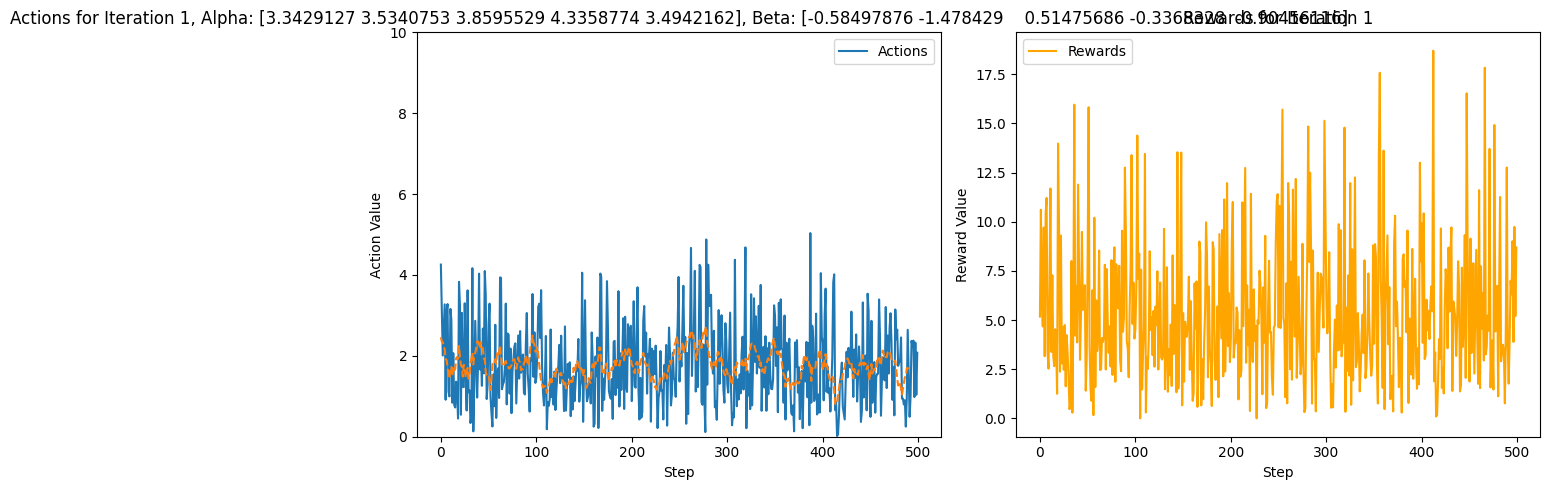

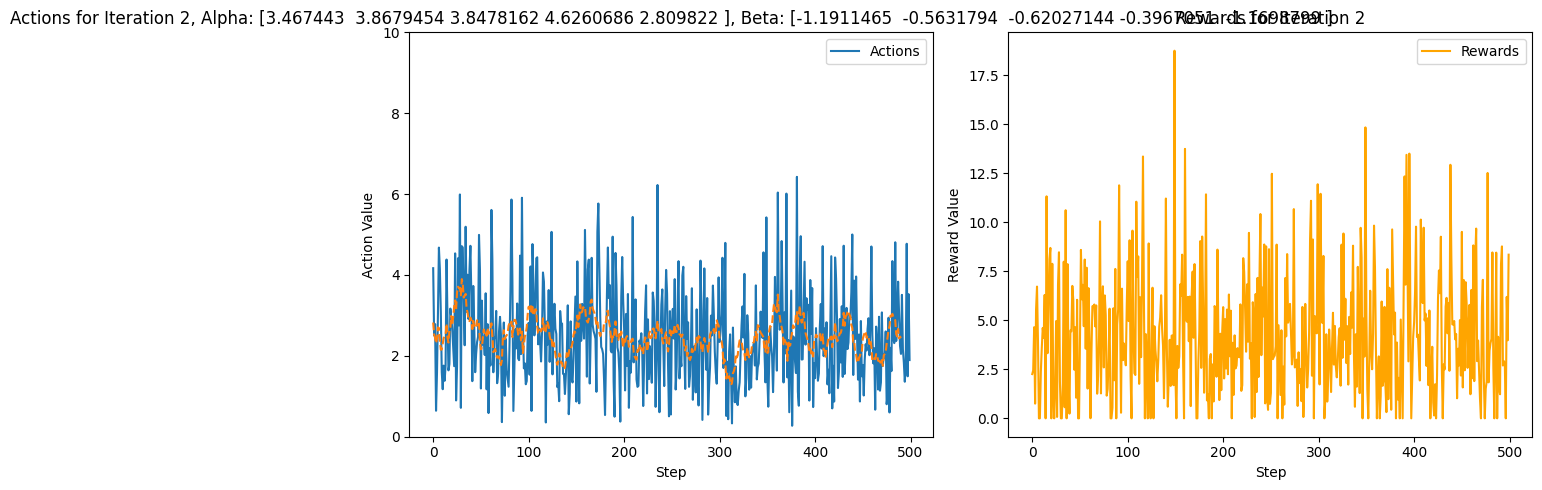

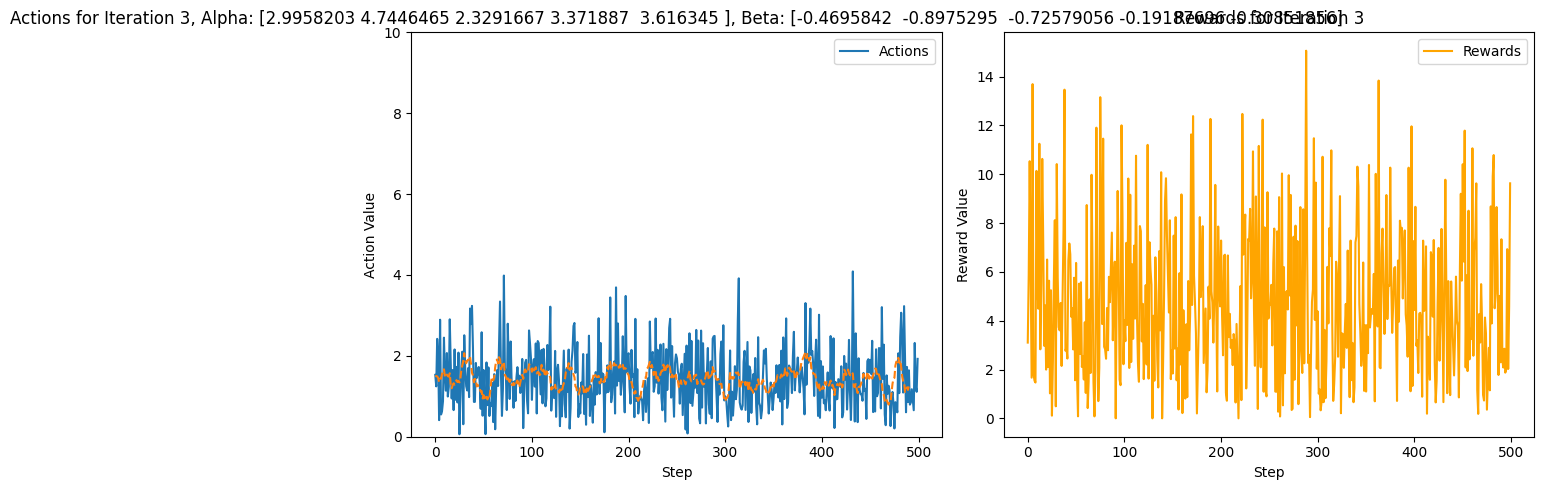

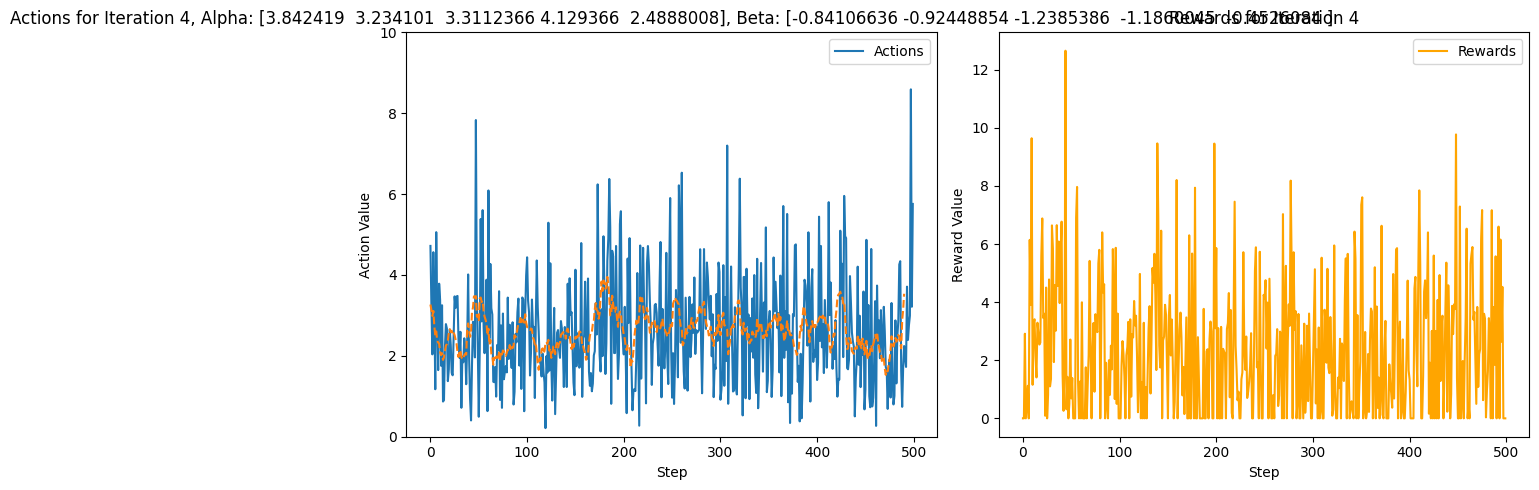

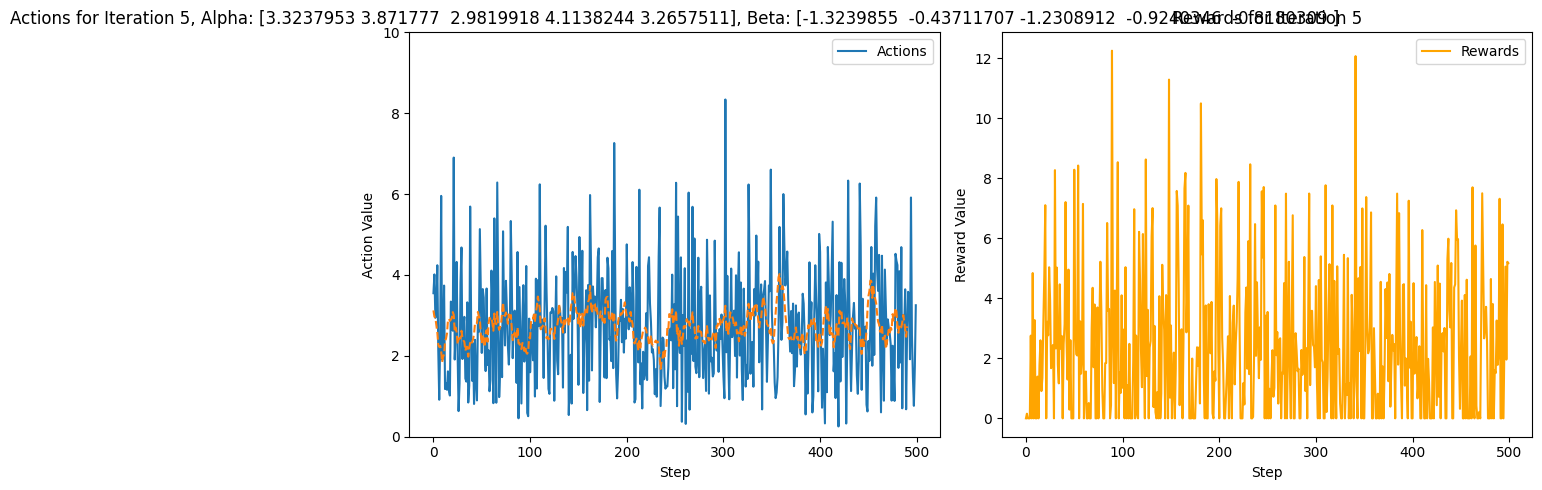

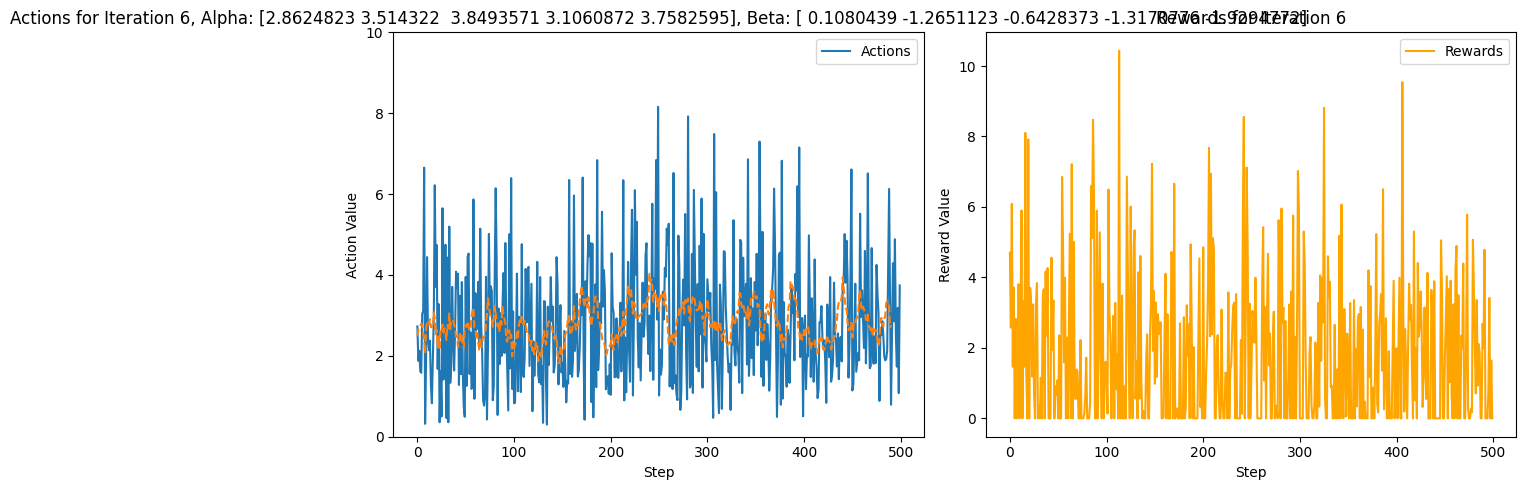

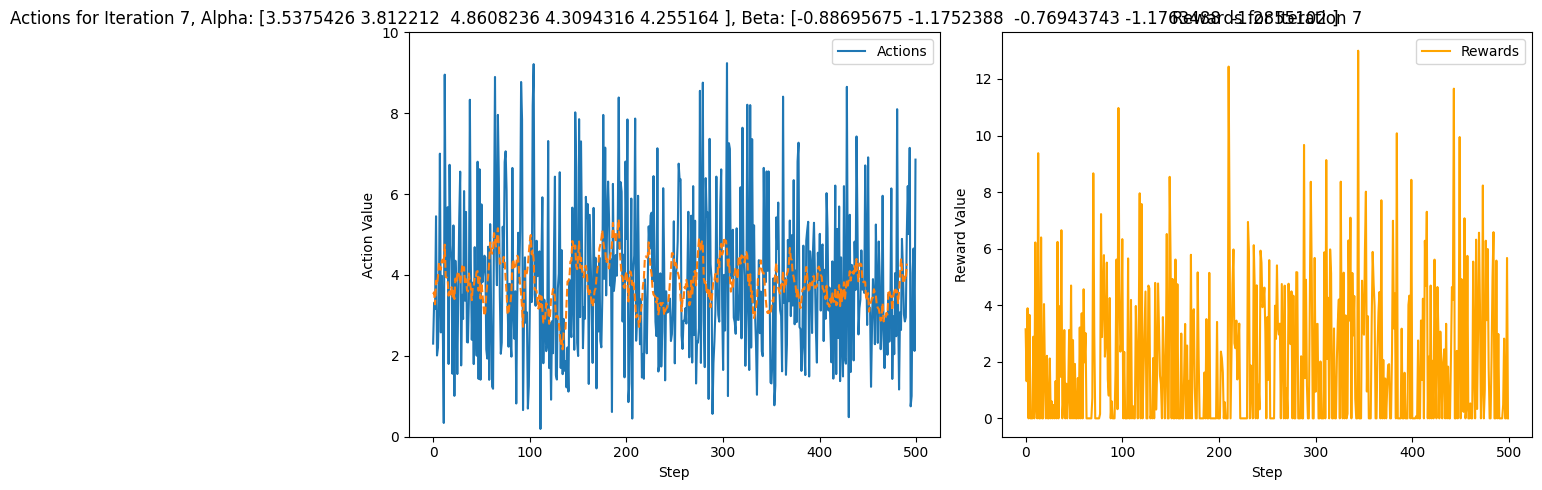

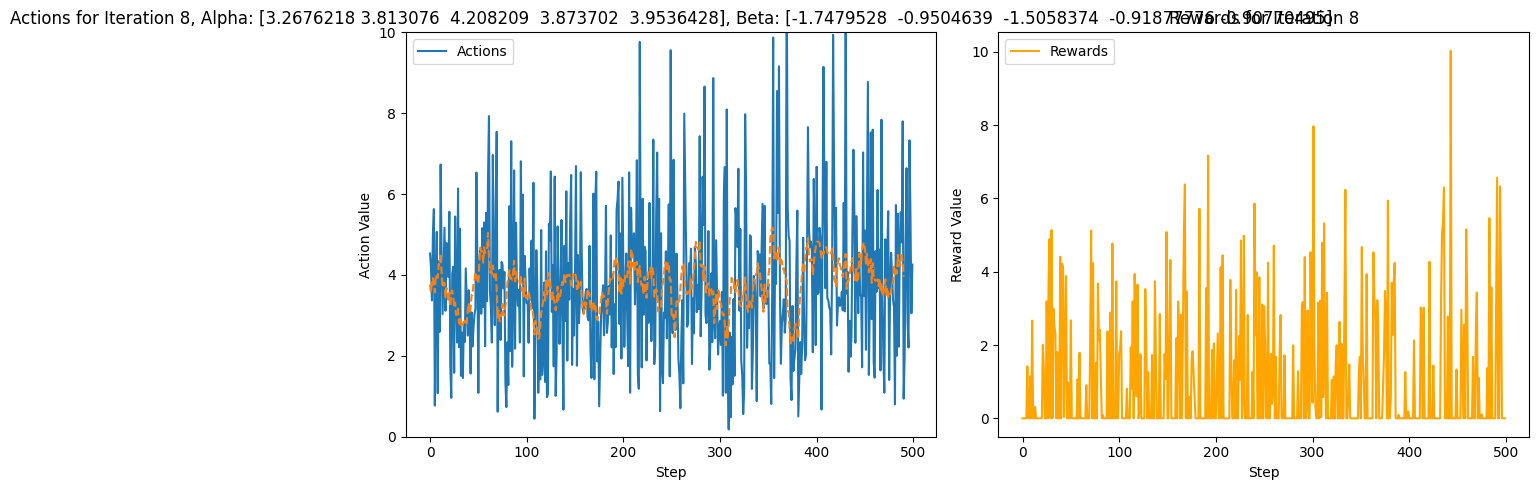

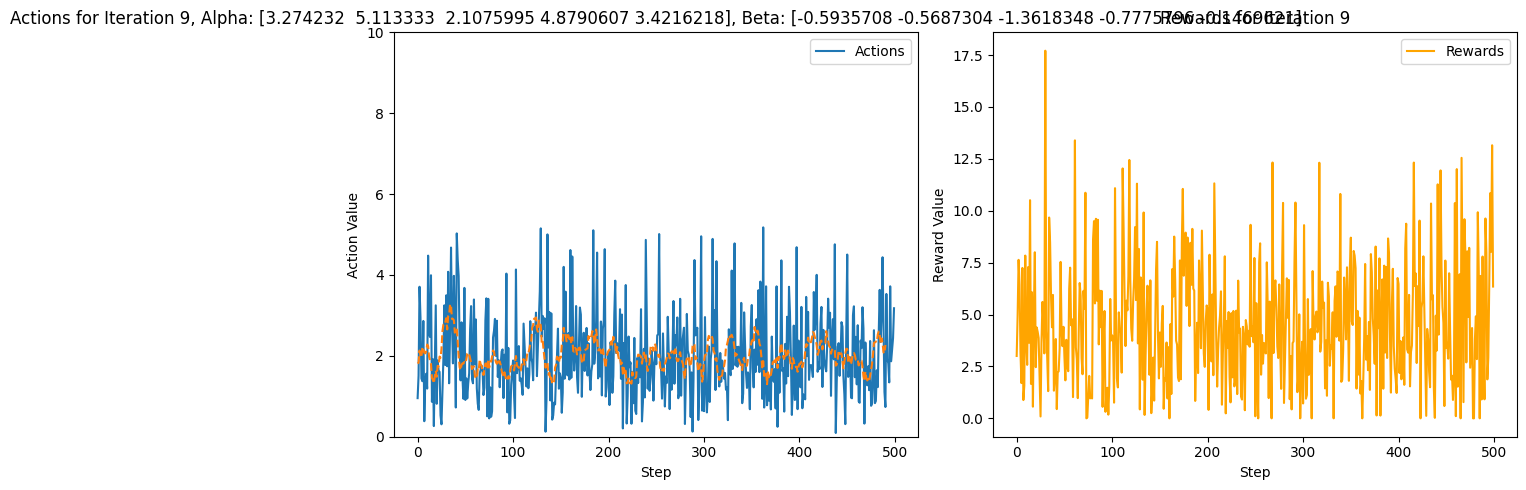

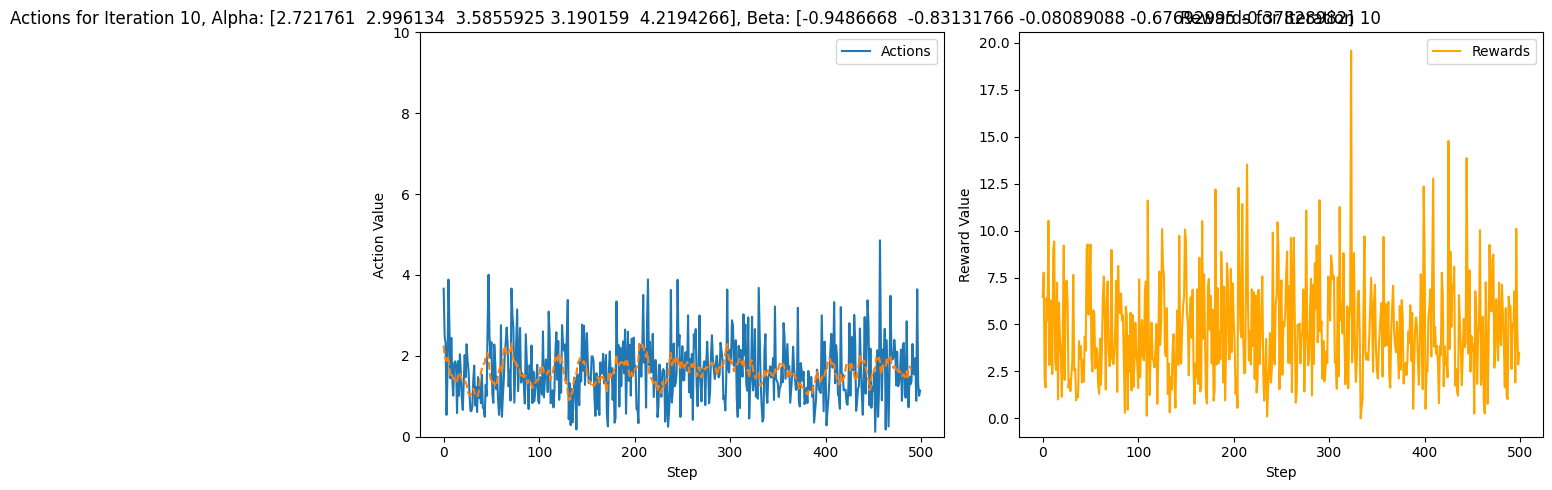

In [ ]:
for i in range(10):
    test_env.reset_task()
    obs = test_env.reset()
    done = False
    step_counter = 0  # Initialize the counter
    alpha = test_env.alpha
    beta = test_env.beta
    actions = []
    rewards = []
    while not done:
        x = obs[:-1]
        action = np.dot(x, alpha) / -2*np.dot(x, beta) 
        obs, reward, done, info = test_env.step(action)
        step_counter += 1  # Increment the counter
        actions.append(action)
        rewards.append(reward)
    

    # Plot actions
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(actions, label='Actions')
    plt.xlabel('Step')
    plt.ylabel('Action Value')
    plt.title(f'Actions for Iteration {i+1}, Alpha: {alpha}, Beta: {beta}')
    plt.ylim(0, 10)  # Set y-axis limits to match action space
    plt.legend()
    # Plot smoothed actions
    smoothed_actions = np.convolve(actions, np.ones(10)/10, mode='valid')
    plt.plot(range(len(smoothed_actions)), smoothed_actions, label='Smoothed Actions', linestyle='--')
    # Plot rewards
    plt.subplot(1, 2, 2)
    plt.plot(rewards, label='Rewards', color='orange')
    plt.xlabel('Step')
    plt.ylabel('Reward Value')
    plt.title(f'Rewards for Iteration {i+1}')
    plt.legend()

    plt.tight_layout()
    plt.show()